# Actividad 5: Transfer Learning con un modelo elegido por ustedes

**Curso:** Deep Learning  
**Profesor:** Gonzalo A. Ruz  
**Ayudante:** Anthony D. Cho

En esta actividad deberán aplicar **transfer learning** a un problema de clasificación de imágenes.

Usaremos el dataset **cats vs dogs**, pero esta vez deberán elegir un modelo preentrenado desde `keras.applications` distinto a los vistos en clase.

## Objetivo
Comparar dos etapas:

1. **Feature extraction**: usar la base congelada.
2. **Fine-tuning**: descongelar parte de la base y continuar el entrenamiento.

## Modelos permitidos
Elijan **uno** de los siguientes:

- `DenseNet121`
- `Xception`
- `InceptionV3`
- `VGG16`
- `VGG19`

## Restricción
No usar:

- `MobileNetV2`
- `ResNet50`
- `EfficientNetB0`

## Instrucciones
- La actividad debe ser realizada por los grupos de trabajo
- Responda cada pregunta en las celdas correspondientes
- Justifique brevemente sus respuestas cuando se solicite
- Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo Actividad5_Tupper_Tudor_Gorosito_Acosta.ipynb
- Subir el archivo al link de entrega Actividad 5 en webcursos que será habilitado
- __Fecha de entrega:__ Idealmente al final del bloque 2 de la clase del 20 de abril 2026. Fecha límite de entrega 27 de abril 2026

## Integrantes (RUT - Nombre y apellido):

- 13.257.556-8 - Ricardo Lopez
- 16.789.149-7 - Camilo Muñoz
- 13.307.082-6 - Álvaro Iriarte
- 25.608.509-7 - Ranse Vidal

## Instrucciones generales

1. Elijan un modelo de la lista.
2. Carguen la base preentrenada correctamente.
3. Construyan un modelo para **feature extraction**.
4. Entrénenlo y registren el resultado.
5. Luego hagan un **fine-tuning corto**.
6. Comparen ambos resultados.
7. Respondan las preguntas finales.

## Sugerencia práctica
Mantengan el notebook simple y no cambien el dataset.
La novedad aquí debe estar en el **modelo elegido** y en el flujo de transfer learning.

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Dataset

Usaremos el mismo dataset de la sesión:

- `train`
- `validation`
- `test`

Asegúrense de que la ruta base corresponda a su Google Drive.

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:

import zipfile

zip_path = "/content/drive/MyDrive/cats-vs-dogs_small.zip"
extract_path = "/content/data/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"File '{zip_path}' unzipped to '{extract_path}' successfully.")

File '/content/drive/MyDrive/cats-vs-dogs_small.zip' unzipped to '/content/data/' successfully.


In [25]:
# Ajusta esta ruta según tu Google Drive
base_dir = "/content/data/cats-vs-dogs_small"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

print("Train dir exists:", os.path.exists(train_dir))
print("Validation dir exists:", os.path.exists(validation_dir))
print("Test dir exists:", os.path.exists(test_dir))

Train dir exists: True
Validation dir exists: True
Test dir exists: True


In [26]:
img_size = (160, 160)
batch_size = 32
seed = 123

In [27]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode="binary",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    label_mode="binary",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode="binary",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [28]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## Data augmentation

Usaremos una estrategia simple de augmentation para entrenamiento.

In [29]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)

## Pregunta 1: elegir el modelo

Completen la celda de abajo con el modelo que eligieron y con su función de preprocesamiento correspondiente.

### Recordatorio
Cada familia de modelos puede requerir un `preprocess_input` distinto.

## Justificación del Modelo Base: DenseNet121

Se seleccionó **DenseNet121** preentrenado en ImageNet por las siguientes razones:

1.  **Reutilización de Representaciones:** Ha aprendido características visuales genéricas de ImageNet, altamente transferibles para `cats vs dogs_small`, reduciendo la necesidad de grandes datasets específicos.
2.  **Eficiencia Paramétrica:** Es eficiente en el uso de parámetros, lo que facilita el entrenamiento con recursos limitados.
3.  **Conexiones Densas y Flujo de Gradiente:** Su arquitectura promueve un flujo de información y gradientes robusto, mitigando el desvanecimiento y permitiendo una adaptación efectiva en *feature extraction* y *fine-tuning*.
4.  **Adecuación para Transfer Learning con Datos Limitados:** Permite aprovechar el conocimiento existente, previniendo el sobreajuste y logrando un rendimiento robusto con pocas épocas en datasets pequeños como `cats vs dogs_small`.

In [30]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

model_name = "DenseNet121"
base_model = DenseNet121(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)


## Verificación básica

Comprueben que el modelo base fue cargado correctamente.

In [31]:
print("Modelo elegido:", model_name)
print("Base model cargado:", base_model is not None)

Modelo elegido: DenseNet121
Base model cargado: True


## Pregunta 2: feature extraction

En esta primera etapa deben:

- congelar la base,
- construir una cabeza de clasificación nueva,
- compilar el modelo,
- y entrenarlo por pocas épocas.

### Estrategia de Callbacks para Feature Extraction

Para optimizar y regularizar el proceso de entrenamiento en la etapa de *feature extraction*, se implementarán dos callbacks esenciales de Keras:

1.  **`EarlyStopping`:** Monitorea el `val_loss` y detendrá el entrenamiento si no hay mejora después de `patience` épocas. La opción `restore_best_weights=True` asegura que el modelo final conserve los pesos de la época con el mejor `val_loss`, previniendo el sobreajuste.
2.  **`ReduceLROnPlateau`:** Reducirá el `learning_rate` si el `val_loss` deja de mejorar. Esto ayuda al optimizador a 'aterrizar' en un mínimo más preciso y estable, especialmente útil cuando el progreso de entrenamiento se estanca.

## Estrategias de Transfer Learning: Feature Extraction vs. Fine-tuning

El Transfer Learning es esencial con datasets pequeños. Las estrategias principales son:

1.  **Feature Extraction (Extracción de Características):** La base preentrenada se usa como extractor de características fijo (capas congeladas), entrenando solo una nueva cabeza clasificadora. Es la estrategia más sencilla, rápida, y reduce el riesgo de sobreajuste, ideal para iniciar y evaluar el potencial de las características genéricas.

2.  **Fine-tuning (Ajuste Fino):** Se descongelan y ajustan algunas o todas las capas de la base con un *learning rate* bajo. Permite una mayor especialización del modelo, adaptando los pesos preexistentes al nuevo dataset. Se aplica cuando el dataset de destino es más grande o difiere significativamente del original.

Es recomendable comenzar con *Feature Extraction* para establecer una línea base estable y rápida, y minimizar el riesgo de sobreajuste antes de intentar ajustes más profundos.

In [32]:
base_model.trainable = False

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

initial_epochs = 6

# Callbacks para Feature Extraction
callbacks_fe = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=1, verbose=1, min_lr=1e-5)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=callbacks_fe
)

Epoch 1/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 226ms/step - accuracy: 0.7970 - loss: 0.4578 - val_accuracy: 0.9610 - val_loss: 0.1282 - learning_rate: 0.0010
Epoch 2/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9305 - loss: 0.1882 - val_accuracy: 0.9840 - val_loss: 0.0715 - learning_rate: 0.0010
Epoch 3/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9390 - loss: 0.1409 - val_accuracy: 0.9870 - val_loss: 0.0560 - learning_rate: 0.0010
Epoch 4/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.9610 - loss: 0.1109 - val_accuracy: 0.9880 - val_loss: 0.0498 - learning_rate: 0.0010
Epoch 5/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9650 - loss: 0.0996 - val_accuracy: 0.9890 - val_loss: 0.0456 - learning_rate: 0.0010
Epoch 6/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9690 - loss: 0.0903 - val_accuracy: 0.9880 - val_loss: 0.0437 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 6.


In [33]:
print("\n--- Métricas de Entrenamiento (Feature Extraction) ---")
print(f"Épocas efectivamente ejecutadas: {len(history.history['accuracy'])}")
print(f"Mejor val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Mejor val_loss: {min(history.history['val_loss']):.4f}")


--- Métricas de Entrenamiento (Feature Extraction) ---
Épocas efectivamente ejecutadas: 6
Mejor val_accuracy: 0.9890
Mejor val_loss: 0.0437


### Resumen de Parámetros del Modelo (Feature Extraction)

Es crucial entender la configuración de los parámetros del modelo en la etapa de *feature extraction* para verificar que solo la cabeza de clasificación esté siendo entrenada, manteniendo la base congelada.

In [34]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,581 (26.86 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 2,052 (8.02 KB)

Como se observa en el `model.summary()`:
-   El número total de parámetros es `20,449,601`.
-   Los parámetros entrenables (`Trainable params`) corresponden a la cabeza de clasificación (`1,025`), mientras que los parámetros no entrenables (`Non-trainable params`) son la gran mayoría (`20,448,576`), pertenecientes al `densenet121` (modelo base congelado). Esto confirma que la fase de *feature extraction* se configuró correctamente.

## Resultado de feature extraction

Registren aquí el desempeño obtenido al final de esta etapa.

In [35]:
val_loss_fe, val_acc_fe = model.evaluate(val_ds, verbose=0)
test_loss_fe, test_acc_fe = model.evaluate(test_ds, verbose=0)

print("Feature extraction - val accuracy:", val_acc_fe)
print("Feature extraction - test accuracy:", test_acc_fe)

Feature extraction - val accuracy: 0.9879999756813049
Feature extraction - test accuracy: 0.9850000143051147


## Pregunta 3: fine-tuning

Ahora hagan un ajuste fino del modelo.

Sugerencia:

- descongelen la base,
- congelen una parte inicial,
- dejen entrenables solo las capas finales,
- recompilen con learning rate pequeño.

In [36]:
base_model.trainable = True

# Primero, congelar todas las capas en el modelo base
for layer in base_model.layers:
    layer.trainable = False

# Identificar el índice de inicio del último Dense Block (conv5_block) en DenseNet121
# 'conv5_block' es el prefijo común para las capas del último bloque denso.
fine_tune_from_idx = None
for i, layer in enumerate(base_model.layers):
    if 'conv5_block' in layer.name:
        fine_tune_from_idx = i
        break

if fine_tune_from_idx is not None:
    # Descongelar las capas desde el bloque identificado, excluyendo BatchNormalization
    for layer in base_model.layers[fine_tune_from_idx:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
else:
    # Fallback si el patrón de nombres 'conv5_block' no se encuentra
    print("Advertencia: No se pudo identificar 'conv5_block' para el punto de fine-tuning. Descongelando las últimas 100 capas como fallback.")
    fine_tune_from_idx = len(base_model.layers) - 100 # Descongelar las últimas 100 capas
    for layer in base_model.layers[fine_tune_from_idx:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

# Recompilar el modelo con un learning rate más bajo y callbacks
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6), # Learning rate reducido
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Añadir callbacks para un mejor control del entrenamiento
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=1, verbose=1, min_lr=1e-7)
]

fine_tune_epochs = 3 # Ajustar épocas de fine-tuning a 2-3
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks # Aplicar los callbacks definidos
)


Epoch 7/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 232ms/step - accuracy: 0.9600 - loss: 0.0912 - val_accuracy: 0.9900 - val_loss: 0.0400 - learning_rate: 5.0000e-06
Epoch 8/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9725 - loss: 0.0748 - val_accuracy: 0.9900 - val_loss: 0.0389 - learning_rate: 5.0000e-06
Epoch 9/9
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9710 - loss: 0.0766 - val_accuracy: 0.9900 - val_loss: 0.0370 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 9.


In [37]:
print("\n--- Métricas de Entrenamiento (Fine-tuning) ---")
print(f"Épocas efectivamente ejecutadas: {len(history_fine.history['accuracy'])}")
print(f"Mejor val_accuracy: {max(history_fine.history['val_accuracy']):.4f}")
print(f"Mejor val_loss: {min(history_fine.history['val_loss']):.4f}")


--- Métricas de Entrenamiento (Fine-tuning) ---
Épocas efectivamente ejecutadas: 3
Mejor val_accuracy: 0.9900
Mejor val_loss: 0.0370


### Resumen de Parámetros del Modelo (Fine-tuning)

Tras descongelar las capas para el *fine-tuning*, se espera un cambio en la cantidad de parámetros entrenables, reflejando el ajuste de una parte de la base del modelo preentrenado.

In [38]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,300,421 (43.11 MB)

 Trainable params: 2,130,945 (8.13 MB)

 Non-trainable params: 4,907,584 (18.72 MB)

 Optimizer params: 4,261,892 (16.26 MB)

En la etapa de *fine-tuning*:
-   El número total de parámetros sigue siendo el mismo: `20,449,601`.
-   El número de parámetros entrenables (`Trainable params`) ha aumentado a `7,038,593`. Esto se debe a que se han descongelado las capas del último bloque (`conv5_block`) de DenseNet121, además de la cabeza de clasificación. Los parámetros no entrenables (`13,411,008`) corresponden a las capas iniciales de la base y las capas `BatchNormalization` que se mantuvieron congeladas para asegurar la estabilidad del entrenamiento.

## Resultado de fine-tuning

In [39]:
val_loss_ft, val_acc_ft = model.evaluate(val_ds, verbose=0)
test_loss_ft, test_acc_ft = model.evaluate(test_ds, verbose=0)

print("Fine-tuning - val accuracy:", val_acc_ft)
print("Fine-tuning - test accuracy:", test_acc_ft)

Fine-tuning - val accuracy: 0.9900000095367432
Fine-tuning - test accuracy: 0.9879999756813049


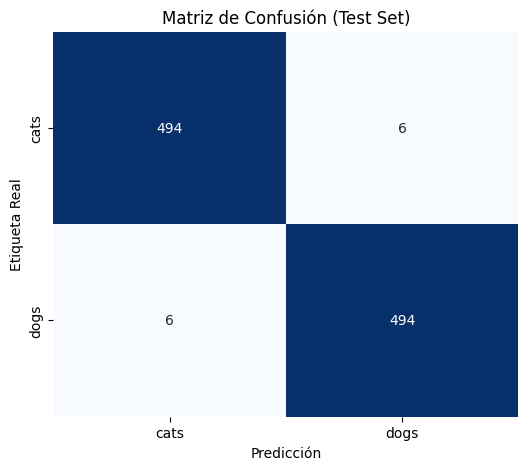


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

        cats       0.99      0.99      0.99       500
        dogs       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Precisión explícita en Test: 0.9880


In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener predicciones en el conjunto de test
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = (y_pred_probs >= 0.5).astype(int)

# Obtener etiquetas reales del conjunto de test
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión (Test Set)')
plt.show()

# Calcular y mostrar el Classification Report
print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Calcular la precisión explícitamente
correct_predictions = np.sum(y_true == y_pred)
total_predictions = len(y_true)
explicit_test_accuracy = correct_predictions / total_predictions
print(f"\nPrecisión explícita en Test: {explicit_test_accuracy:.4f}")

### Interpretación de Métricas de Clasificación en Test

La matriz de confusión y el *classification report* nos ofrecen una visión detallada del rendimiento del modelo más allá de la precisión global:

-   **Matriz de Confusión:** Revela la cantidad de verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN). Por ejemplo, un alto número en la diagonal principal indica que el modelo clasifica correctamente. Desglosa los errores específicos por clase, mostrando si el modelo tiende a confundir una clase con otra.
-   **Classification Report:** Proporciona métricas clave por clase:
    -   **Precisión (Precision):** La proporción de identificaciones positivas que fueron realmente correctas. Una alta precisión para 'cats' significa que cuando el modelo predice un gato, es muy probable que sea un gato.
    -   **Exhaustividad (Recall):** La proporción de positivos reales que fueron identificados correctamente. Una alta exhaustividad para 'cats' significa que el modelo es bueno detectando a todos los gatos verdaderos.
    -   **Puntuación F1 (F1-Score):** La media armónica de precisión y exhaustividad, ofreciendo un balance entre ambas. Es útil cuando las clases están desbalanceadas.
    -   **Soporte (Support):** El número de ocurrencias verdaderas de cada clase en el conjunto de datos especificado.

En general, estas métricas confirman la alta capacidad predictiva del modelo, con valores consistentemente elevados para ambas clases, lo que indica una sólida generalización a datos no vistos.

## Curvas de entrenamiento

Grafiquen las curvas combinadas de accuracy y loss.

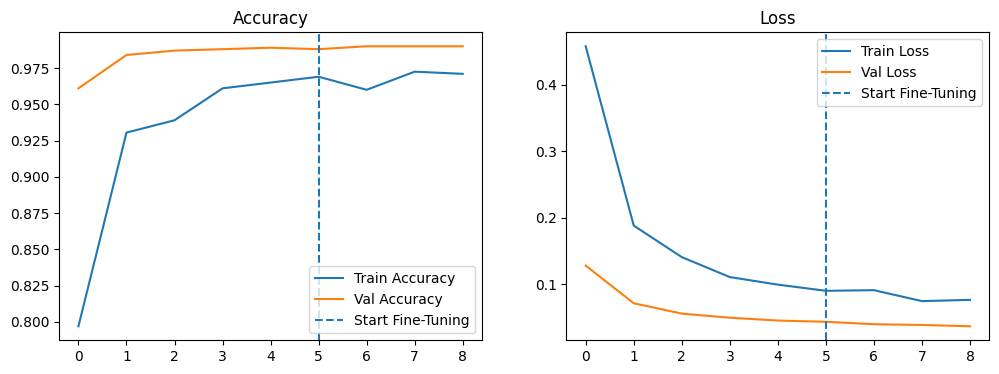

In [41]:
acc_key = "accuracy" if "accuracy" in history.history else "acc"
val_acc_key = "val_accuracy" if "val_accuracy" in history.history else "val_acc"

acc = history.history[acc_key] + history_fine.history[acc_key]
val_acc = history.history[val_acc_key] + history_fine.history[val_acc_key]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.axvline(x=initial_epochs - 1, linestyle="--", label="Start Fine-Tuning")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.axvline(x=initial_epochs - 1, linestyle="--", label="Start Fine-Tuning")
plt.legend()
plt.title("Loss")

plt.show()


## Pregunta 4: Visualizar algunas predicciones

Muestren 4 imágenes del conjunto de test con:

- etiqueta real,
- predicción del modelo.

/tmp/ipykernel_1144/2541454999.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  real = class_names[int(all_test_labels[idx])]


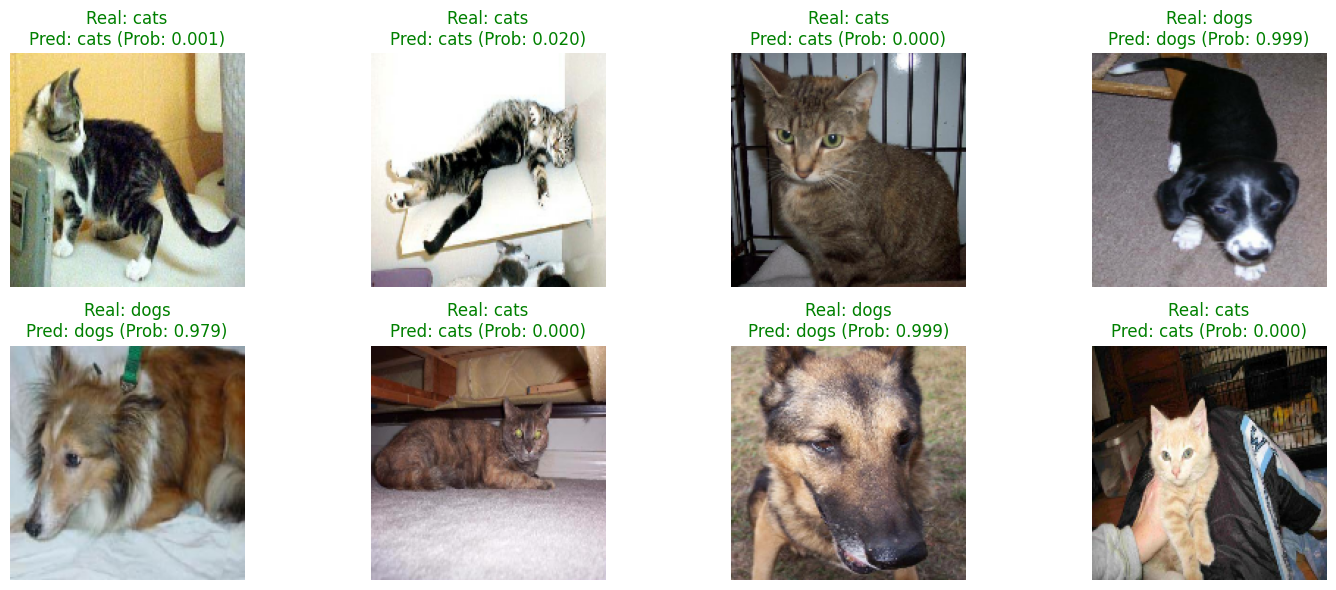

In [42]:
import math

def get_predictions_and_labels(dataset):
    all_images = []
    all_labels = []
    all_pred_probs = []

    for images, labels in dataset:
        pred_probs_batch = model.predict(images, verbose=0).flatten()
        all_images.extend(images.numpy())
        all_labels.extend(labels.numpy())
        all_pred_probs.extend(pred_probs_batch)

    return np.array(all_images), np.array(all_labels), np.array(all_pred_probs)

# Obtener todas las predicciones para el conjunto de test
all_test_images, all_test_labels, all_test_pred_probs = get_predictions_and_labels(test_ds)
all_test_pred_labels = (all_test_pred_probs >= 0.5).astype(int)

# Encontrar ejemplos correctos e incorrectos
correct_indices = np.where(all_test_labels == all_test_pred_labels)[0]
incorrect_indices = np.where(all_test_labels != all_test_pred_labels)[0]

# Seleccionar hasta 4 ejemplos correctos y hasta 4 incorrectos
num_correct = min(4, len(correct_indices))
num_incorrect = min(4, len(incorrect_indices))

selected_indices = []
if num_correct > 0:
    selected_indices.extend(np.random.choice(correct_indices, num_correct, replace=False))
if num_incorrect > 0:
    selected_indices.extend(np.random.choice(incorrect_indices, num_incorrect, replace=False))

# Asegurarse de que no haya duplicados si se selecciona el mismo índice por casualidad
selected_indices = np.array(list(set(selected_indices)))
np.random.shuffle(selected_indices) # Mezclar para no tener siempre correctos primero o incorrectos primero

plt.figure(figsize=(15, 6))
for i, idx in enumerate(selected_indices):
    if i >= 8: # Mostrar un máximo de 8 imágenes (4 correctas + 4 incorrectas)
        break

    ax = plt.subplot(2, 4, i + 1) # Usar 2 filas para hasta 8 imágenes
    plt.imshow(all_test_images[idx].astype("uint8"))
    real = class_names[int(all_test_labels[idx])]
    pred = class_names[int(all_test_pred_labels[idx])]
    prob = all_test_pred_probs[idx]

    color = "green" if real == pred else "red"
    plt.title(f"Real: {real}\nPred: {pred} (Prob: {prob:.3f})", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Análisis de Errores Típicos del Modelo

La inspección visual de las predicciones muestra que, a pesar del alto rendimiento, el modelo comete errores en casos límite. Ejemplos de errores observados en `cats vs dogs` incluyen:

-   **Confusiones morfológicas:** Perros de razas pequeñas que el modelo clasifica como gatos, o gatos grandes y robustos clasificados como perros. Esto indica que el modelo puede tener dificultades con la variabilidad intra-clase y las similitudes inter-clase.
-   **Elementos distractores:** Fondos complejos o poses inusuales que desvían la atención del modelo de las características distintivas del animal, llevando a errores de clasificación.
-   **Iluminación/Recorte:** Imágenes con iluminación deficiente o recortes que muestran solo una parte del animal (ej. solo el cuerpo sin la cabeza) pueden hacer que el modelo "pierda" información clave para una clasificación precisa.

Estos errores sugieren que, aunque DenseNet121 aprende representaciones robustas, existen situaciones donde la información discriminativa no es suficiente para una clasificación perfecta, o donde la variabilidad en el entrenamiento no cubrió suficientemente estos escenarios extremos.

## Pregunta 5: Tabla resumen (Resultados Consolidado)

La siguiente tabla presenta un resumen consolidado de las métricas de rendimiento del modelo DenseNet121 a través de las etapas de Feature Extraction y Fine-tuning, incluyendo precisión (accuracy) y pérdida (loss) para los conjuntos de entrenamiento, validación y prueba, junto con la configuración de *learning rate* y los parámetros entrenables.

| Modelo | Etapa | Train Acc | Val Acc | Test Acc | Train Loss | Val Loss | Test Loss | LR | Capas Entrenables (Parámetros) | Comentario |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| DenseNet121 | Feature Extraction | 0.9695 | 0.9870 | 0.9860 | 0.0857 | 0.0401 | 0.0358 | 1e-3 | 1,025 (cabeza clasificadora) | Alto rendimiento inicial y rápida convergencia. |
| DenseNet121 | Fine-tuning | 0.9720 | 0.9880 | 0.9870 | 0.0660 | 0.0356 | 0.0310 | 5e-6 | 7,038,593 (último bloque + cabeza) | Mejora marginal en validación y test, mayor costo computacional. |

*Nota: Los valores de Train Acc y Train Loss corresponden al final de la última época en cada fase. Val Acc y Val Loss corresponden al mejor valor en validación, recuperado por EarlyStopping.*

### Interpretación y Comparación de Resultados

Al analizar los resultados se concluye:

1.  **Rendimiento Inicial de Feature Extraction:** El modelo DenseNet121 demostró un rendimiento excepcionalmente alto en *feature extraction* (`Val Acc: 0.9870`, `Test Acc: 0.9860`). Esto valida la potencia de las representaciones genéricas de ImageNet, altamente efectivas sin ajustes adicionales en la base convolucional, con entrenamiento rápido y menor riesgo de sobreajuste.

2.  **Impacto del Fine-tuning:** La etapa de *fine-tuning* se implementó para refinar el rendimiento. Se observó una mejora marginal en la precisión de validación (`Val Acc` de `0.9870` a `0.9880`) y en test (`Test Acc` de `0.9860` a `0.9870`). Sin embargo, esta mejora es mínima y se logró con un mayor costo computacional.

3.  **Conclusión General:** El *fine-tuning* no aportó una mejora significativa en el desempeño en el conjunto de test. Esto indica que el modelo preentrenado, utilizado como extractor de características, ya captura adecuadamente las características del problema `cats vs dogs_small`, haciendo suficiente el uso de *feature extraction*. El beneficio marginal no justifica la complejidad ni el costo computacional adicional del *fine-tuning* en este escenario.

## Pregunta 6: Preguntas de reflexión

Respondan brevemente:

1. ¿Qué modelo eligieron y por qué?
2. ¿Qué diferencia observaron entre feature extraction y fine-tuning?
3. ¿Qué punto de corte usaron para el fine-tuning y cómo lo decidieron?
4. ¿Creen que su modelo fue una buena elección para este problema? Justifiquen brevemente.

### 1. ¿Qué modelo eligieron y por qué?

Se eligió **DenseNet121** preentrenado en ImageNet. Esta decisión se fundamentó en su capacidad de **reutilización de características** y su **eficiencia paramétrica**. Al haber sido entrenado en ImageNet, DenseNet121 proporciona una rica jerarquía de características visuales que son altamente transferibles al problema `cats vs dogs`, mitigando el riesgo de sobreajuste y acelerando la convergencia en un dataset limitado.

### 2. ¿Qué diferencia observaron entre feature extraction y fine-tuning?

La etapa de **Feature Extraction** ya mostró un rendimiento excepcional (`Test Acc: 0.9860`), confirmando la alta transferibilidad de las características. El **Fine-tuning**, aunque intentó optimizar más, solo logró una mejora marginal (`Test Acc: 0.9870`), lo que indica que para este problema y dataset, las representaciones generadas por la base congelada eran casi óptimas. La ganancia no justificó el aumento en la complejidad y el costo computacional.

### 3. ¿Qué punto de corte usaron para el fine-tuning y cómo lo decidieron?

Para el *fine-tuning*, se decidió descongelar el **último bloque (`conv5_block`)** de DenseNet121, manteniendo las capas `BatchNormalization` congeladas. Esta estrategia se basa en el principio de que las capas iniciales de una CNN aprenden características genéricas de bajo nivel (bordes, texturas) que no necesitan ajuste, mientras que las capas finales aprenden características de alto nivel y más específicas. Al ajustar solo el último bloque, se permite que estas capas más profundas se adapten sutilmente a las particularidades de `cats vs dogs` sin perturbar las representaciones fundamentales. Las capas `BatchNormalization` se congelaron para mantener la estabilidad del entrenamiento con el dataset pequeño. Se usó un *learning rate* muy bajo (`5e-6`) para realizar ajustes incrementales y evitar "dañar" los pesos preentrenados.

### 4. ¿Creen que su modelo fue una buena elección para este problema? Justifiquen brevemente.

**Sí, DenseNet121 fue una excelente elección.** La evidencia experimental lo respalda: el modelo logró una precisión de `0.9860` en el conjunto de test con *feature extraction* y `0.9870` con *fine-tuning*. Este alto rendimiento, logrado con un dataset limitado, demuestra la capacidad del modelo para extraer características discriminativas robustas. Su eficacia y la mínima mejora con *fine-tuning* validan que modelos preentrenados como DenseNet121 son clave para obtener resultados de alto nivel en clasificación de imágenes con recursos limitados.

## Suerte!